In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# Experiment sets

shots = 1024
n_values = [1, 3, 5, 7, 9]
p_values = np.arange(0, 1.01, 0.05)

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "D(P)1_before_H": qa.depolarizing.deutsch_jozsa_depolarizing1,
    "D(P)2_after_first_H": qa.depolarizing.deutsch_jozsa_depolarizing2,
    "D(P)3_after_oracle": qa.depolarizing.deutsch_jozsa_depolarizing3,
    "D(P)4_after_final_H": qa.depolarizing.deutsch_jozsa_depolarizing4,
}


results = []

for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)

        probs_ref = qa.deutsch_jozsa.measure_probs_first_n(state_ref, n)
        probs_ref = qa.depolarizing.clean_probs(probs_ref)

        samples_ref = qa.deutsch_jozsa.sample_probs(probs_ref, shots)
        P0_ref = samples_ref[0] / shots

        for p in p_values:

            results.append({
                "n": n,
                "p": p,
                "target_qubit": target_qubit,
                "function": function_name,
                "error_position": "no_error",
                "P0": P0_ref,
                "shots": shots,
            })

            for error_name, error_function in error_positions.items():

                rho_error = error_function(n, f, p, target_qubit)

                probs_error = qa.depolarizing.measure_probs_first_n_rho(
                    rho_error,
                    n
                )

                probs_error = qa.depolarizing.clean_probs(probs_error)

                samples_error = qa.deutsch_jozsa.sample_probs(
                    probs_error,
                    shots
                )

                P0_error = samples_error[0] / shots

                results.append({
                    "n": n,
                    "p": p,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": error_name,
                    "P0": P0_error,
                    "shots": shots,
                })

df_dep = pd.DataFrame(results)

df_dep.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9


,n,p,target_qubit,function,error_position,P0,shots
0,1,0.0,0,constant_1,no_error,1.0,1024
1,1,0.0,0,constant_1,D(P)1_before_H,1.0,1024
2,1,0.0,0,constant_1,D(P)2_after_first_H,1.0,1024
3,1,0.0,0,constant_1,D(P)3_after_oracle,1.0,1024
4,1,0.0,0,constant_1,D(P)4_after_final_H,1.0,1024


In [3]:
df_dep.to_csv("dja_depolarizing_results_shots_1024.csv", index=False)

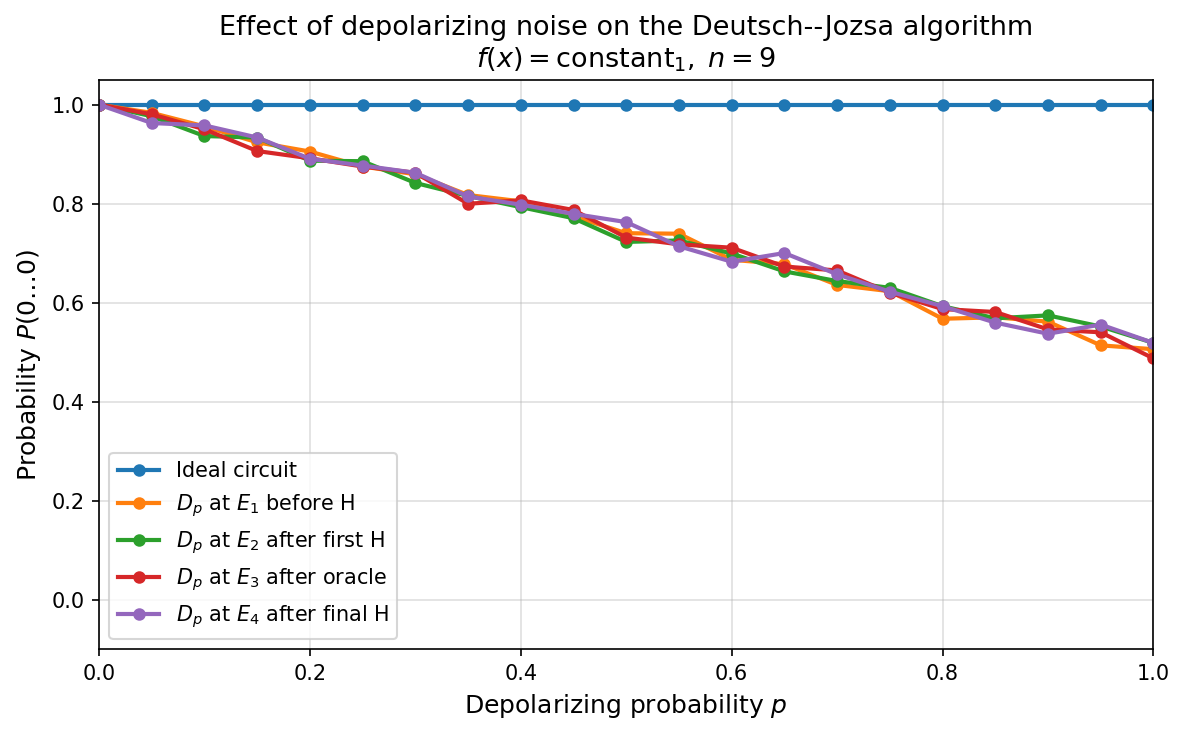

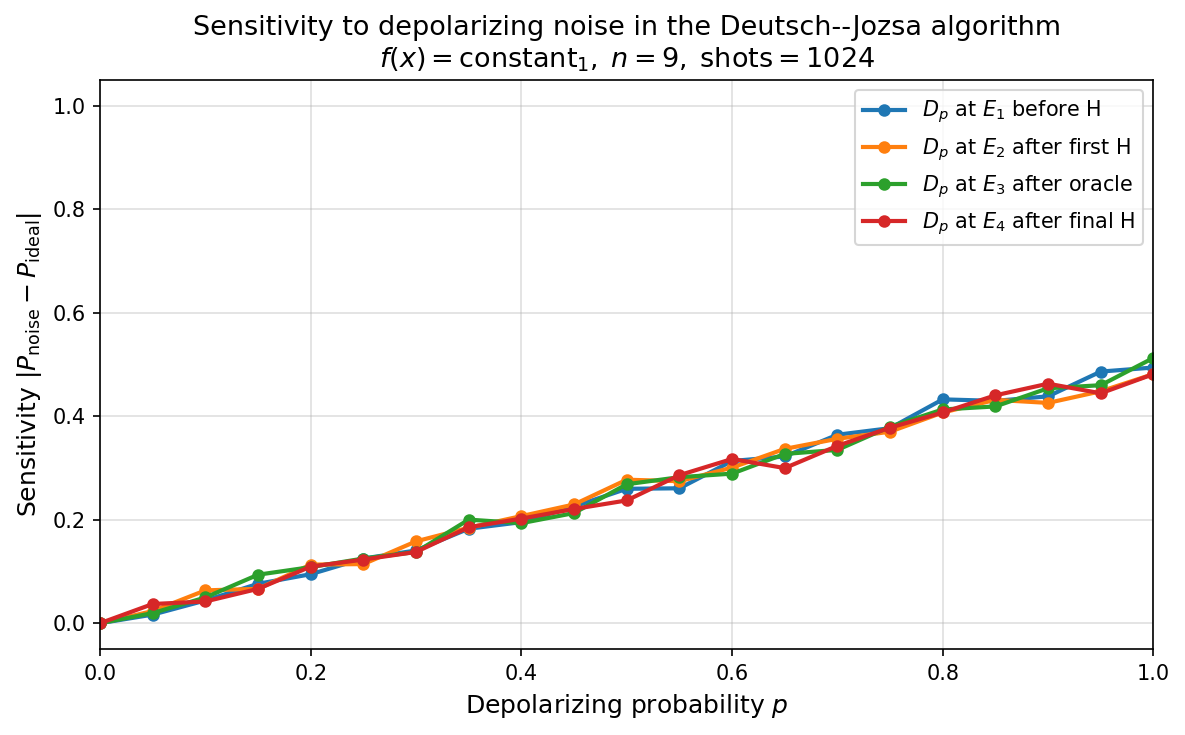

In [9]:
qa.plotting.plot_depolarizing_positions(
    df_dep,
    n_plot=9,
    function_plot="constant_1"
)

qa.plotting.plot_depolarizing_sensitivity(
    df_dep,
    n_plot=9,
    function_plot="constant_1",
    shots=shots
)

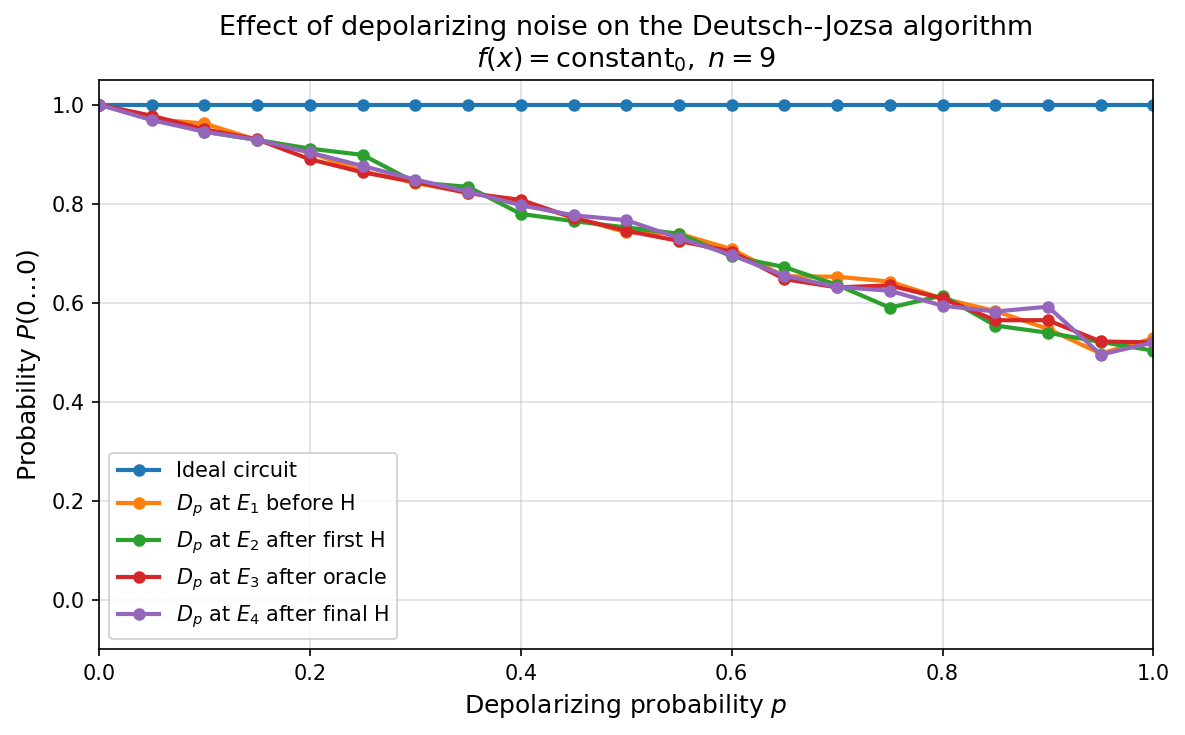

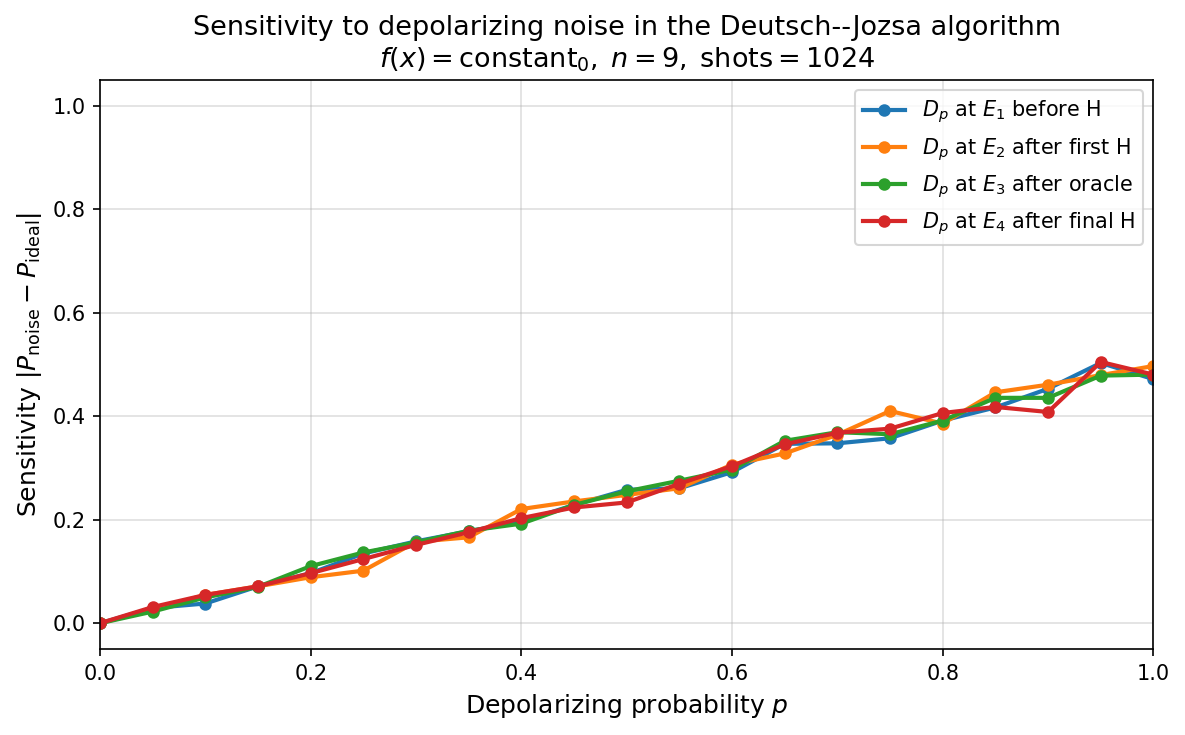

In [7]:
qa.plotting.plot_depolarizing_positions(
    df_dep,
    n_plot=9,
    function_plot="constant_0"
)

qa.plotting.plot_depolarizing_sensitivity(
    df_dep,
    n_plot=9,
    function_plot="constant_0",
    shots=shots
)


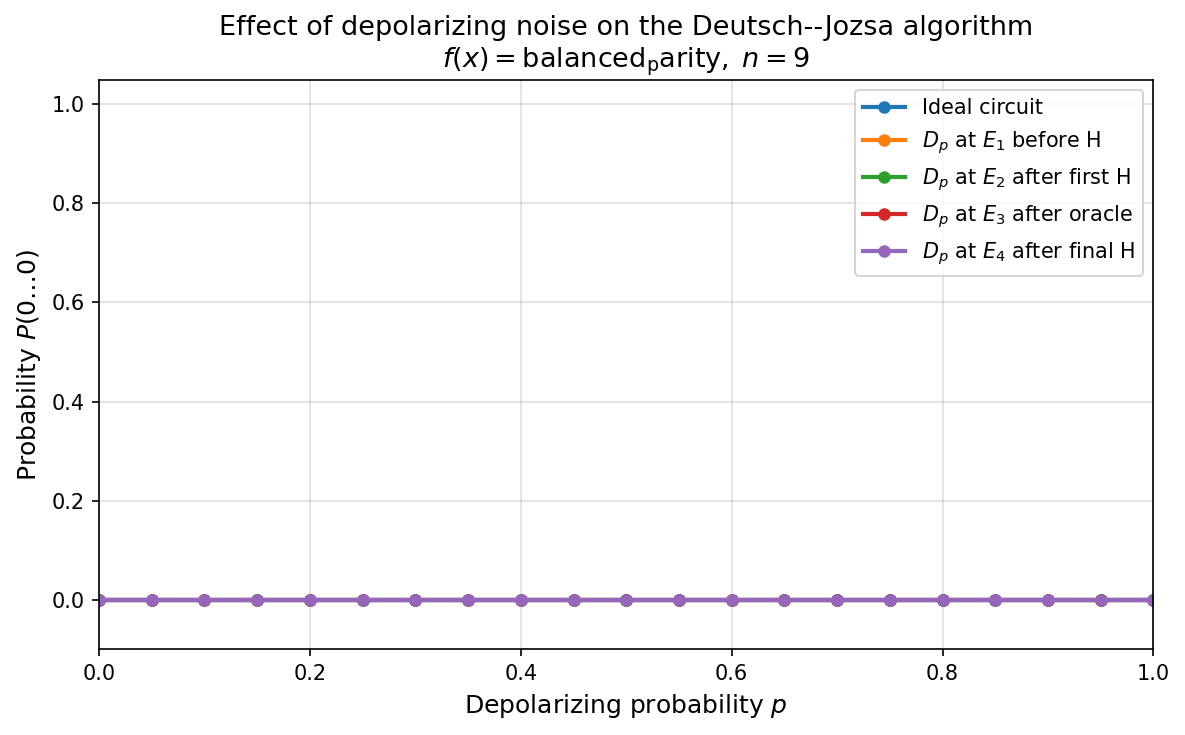

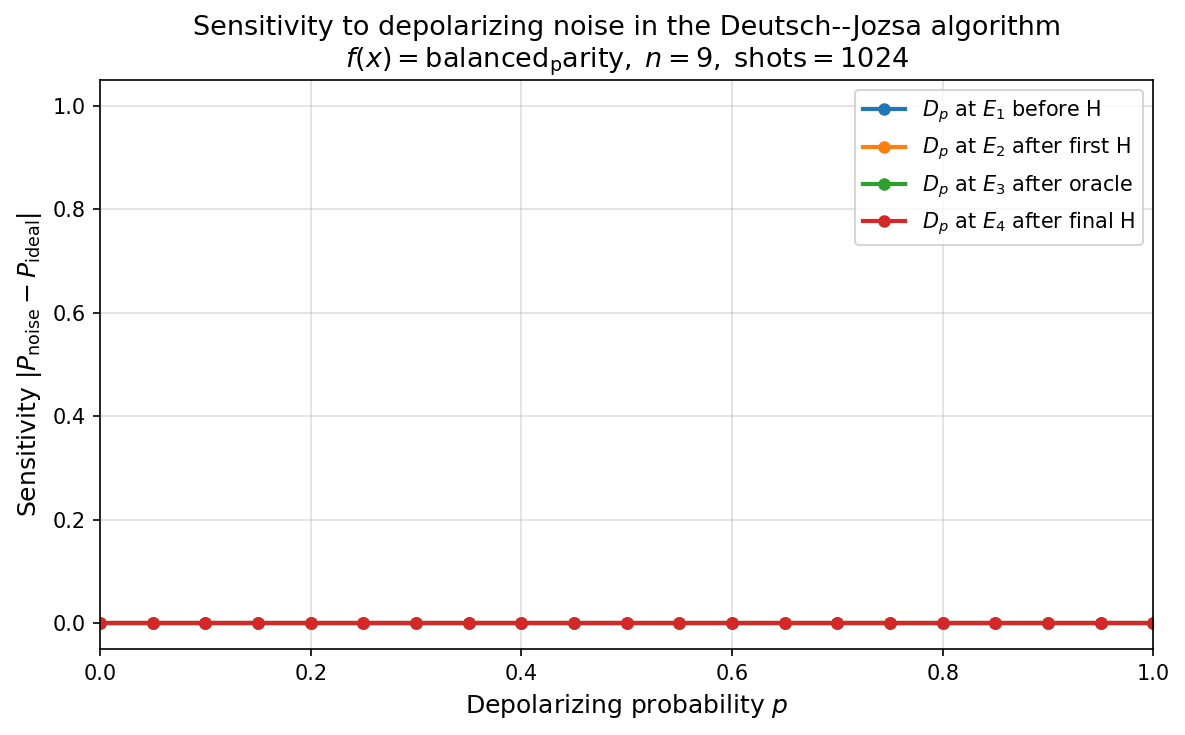

In [ ]:
qa.plotting.plot_depolarizing_positions(
    df_dep,
    n_plot=9,
    function_plot="balanced_parity"
)

qa.plotting.plot_depolarizing_sensitivity(
    df_dep,
    n_plot=9,
    function_plot="balanced_parity",
    shots=shots
)